In [2]:
import pandas as pd
from sklearn import metrics
from scipy.io import loadmat
from os.path import exists
from tqdm import tqdm
from scipy.linalg import toeplitz
import time
import scipy
import os
import matplotlib.colors as mcolors 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import reload
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import cooler
import cooltools
import glob
import scanpy as sc
import math

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
import utils as ut
import matrix

## Pore-C

In [3]:
resolution = 1000000
chrom = "chr7"

dpath = "/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/by_chromosome/"

file_list = sorted(glob.glob(f"{dpath}*_{resolution}_{chrom}*"))
print(file_list)

population_path = file_list[0]
singlecell_path = file_list[1]

print()

print(f"{population_path=}")
print(f"{singlecell_path=}")

['/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/by_chromosome/population_mESC_1000000_chr7.h5ad', '/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/by_chromosome/singlecell_mESC_1000000_chr7.h5ad']

population_path='/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/by_chromosome/population_mESC_1000000_chr7.h5ad'
singlecell_path='/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/by_chromosome/singlecell_mESC_1000000_chr7.h5ad'


In [4]:
# population
start_time = time.time()  # Record the start time
adata = sc.read_h5ad(population_path)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()
adata

Time taken to read the file: 2.85 seconds
Memory usage: current 0.56 GB, difference +0.56 GB


/scratch/indikar_root/indikar1/sgolts/conda-envs/pore_c/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 142 × 85534
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII', 'chrom_degree'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes', 'chrom_order'
    uns: 'base_resolution', 'chrom_sizes', 'gene_map'

In [5]:
# single cell
start_time = time.time()  # Record the start time
bdata = sc.read_h5ad(singlecell_path)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()
bdata

Time taken to read the file: 11.73 seconds
Memory usage: current 1.52 GB, difference +0.96 GB


/scratch/indikar_root/indikar1/sgolts/conda-envs/pore_c/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 142 × 851428
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII', 'chrom_degree'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes', 'chrom_order'
    uns: 'base_resolution', 'chrom_sizes', 'gene_map'

In [6]:
def find_outliers_iqr(df_column):
  """
  Identifies outliers in a pandas DataFrame column using the IQR method.

  Args:
    df_column: A pandas Series representing the column to analyze.

  Returns:
    A boolean mask with True for outliers and False otherwise.
  """
  Q1 = df_column.quantile(0.15)
  Q3 = df_column.quantile(0.85)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  return (df_column < lower_bound) | (df_column > upper_bound)

adata.obs['degree_outlier'] = find_outliers_iqr(adata.obs['chrom_degree'])
adata.obs[['chrom_bin', 'chrom_degree', 'degree_outlier']].sort_values(by='chrom_degree', ascending=False).head()

,chrom_bin,chrom_degree,degree_outlier
bin_name,,,
chr7:7,7,2476,True
chr7:8,8,2416,True
chr7:9,9,2147,False
chr7:40,40,2021,False
chr7:15,15,1942,False


In [7]:
# bdata.obs['degree_outlier'] = find_outliers_iqr(bdata.obs['chrom_degree'])
# bdata.obs[['chrom_bin', 'chrom_degree', 'degree_outlier']].sort_values(by='chrom_degree', ascending=False).head()

In [8]:
matrix.expand_and_normalize_anndata(adata, oe_kr=False)
#print()
matrix.expand_and_normalize_anndata(bdata, oe_kr=False)

Expanding input matrix...
Applying KR normalization...
Applying OE normalization...
Normalization complete.
Expanding input matrix...
Applying KR normalization...
Applying OE normalization...
Normalization complete.


A.shape=(137, 137) B.shape=(137, 137)


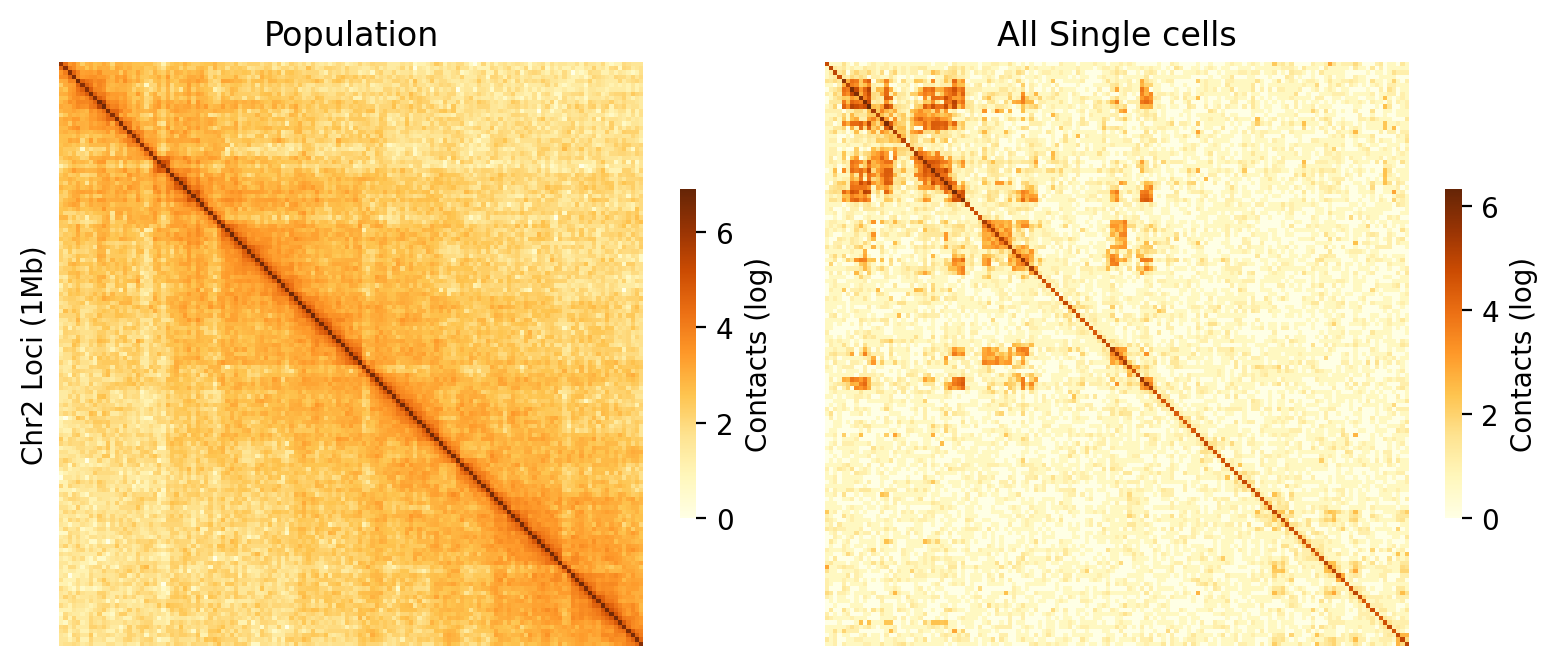

In [9]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 5

cmap = 'YlOrBr'
layer = 'A'
log = True
A = adata.obsm[layer]
B = bdata.obsm[layer]

# remove outliers
outliers = adata.obs[adata.obs['degree_outlier']].index.to_list()

A = A.drop(outliers, axis=0).drop(outliers, axis=1)
B = B.drop(outliers, axis=0).drop(outliers, axis=1)

cbar_label = f"Contacts"

if log:
    A = np.log1p(A)
    B = np.log1p(B)
    cbar_label = f"Contacts (log)"

print(f"{A.shape=} {B.shape=}")

fig, axs = plt.subplots(1, 2, sharey=True)
axs = axs.ravel()

sns.heatmap(
    A,
    square=True,
    cmap=cmap,
    cbar_kws={'shrink' : 0.35, 'label' : cbar_label},
    ax=axs[0],
)

axs[0].set_yticks([])
axs[0].set_xticks([])
axs[0].set_title(f"Population")
axs[0].set_xlabel("")
axs[0].set_ylabel(f"Chr2 Loci (1Mb)")

sns.heatmap(
    B,
    square=True,
    cmap=cmap,
    cbar_kws={'shrink' : 0.35, 'label' : cbar_label},
    ax=axs[1],
)

axs[1].set_yticks([])
axs[1].set_xticks([])
axs[1].set_title(f"All Single cells")
axs[1].set_xlabel("")
axs[1].set_ylabel(f"")

plt.tight_layout()

In [10]:
incidence_matrices = {}
cell_ids = bdata.var['basename'].unique()

# Only take the first 20 cells
cell_ids_subset = cell_ids[:20]
num_cells = len(cell_ids_subset)
total_time = 0.0

for i, cell_id in enumerate(cell_ids_subset):
    start_time = time.time()

    # extract the single-cell
    sc_data = bdata[:, bdata.var['basename'] == cell_id].copy()
    H_o = sc_data.to_df()
    H_o = H_o.T.drop_duplicates().T  # Transpose, drop duplicates, transpose back
    H_o.columns = [f"{cell_id}_{x}" for x in H_o.columns]

    incidence_matrices[cell_id] = H_o

    # Timing info
    elapsed_time = time.time() - start_time
    total_time += elapsed_time

    print(f"Processed {i+1}/{num_cells} cells. "
          f"Time for this cell: {elapsed_time:.2f} seconds, "
          f"Cumulative time: {total_time:.2f} seconds")

print("Finished processing cells.")

Processed 1/20 cells. Time for this cell: 0.92 seconds, Cumulative time: 0.92 seconds
Processed 2/20 cells. Time for this cell: 0.21 seconds, Cumulative time: 1.13 seconds
Processed 3/20 cells. Time for this cell: 0.20 seconds, Cumulative time: 1.34 seconds
Processed 4/20 cells. Time for this cell: 0.19 seconds, Cumulative time: 1.53 seconds
Processed 5/20 cells. Time for this cell: 0.23 seconds, Cumulative time: 1.76 seconds
Processed 6/20 cells. Time for this cell: 0.18 seconds, Cumulative time: 1.95 seconds
Processed 7/20 cells. Time for this cell: 0.19 seconds, Cumulative time: 2.14 seconds
Processed 8/20 cells. Time for this cell: 0.21 seconds, Cumulative time: 2.34 seconds
Processed 9/20 cells. Time for this cell: 0.20 seconds, Cumulative time: 2.54 seconds
Processed 10/20 cells. Time for this cell: 0.18 seconds, Cumulative time: 2.73 seconds
Processed 11/20 cells. Time for this cell: 0.20 seconds, Cumulative time: 2.92 seconds
Processed 12/20 cells. Time for this cell: 0.19 seco

In [11]:
# def plot_clique_from_incidence(
#     H: pd.DataFrame,
#     title: str = "",
#     drop_outliers: bool = False,
#     outlier_threshold: float = 1.5,
#     cmap: str = "Reds",
#     dpi: int = 300,
#     figsize=(7,7),
#     save_path: str | None = None
# ):
#     # 1) Clique-expand
#     A = matrix.clique_expand_incidence(H, zero_diag=False)

#     # 2) Sort rows/cols
#     A = A.sort_index(axis=0)
#     A = A.sort_index(axis=1)

#     # # 3) Optionally drop outlier/repeat rows+cols
#     # if drop_outliers:
#     #     outlier_indices = matrix.find_outlier_row_indices(A, threshold=outlier_threshold)
#     #     print(f"{title} -> outlier_indices={outlier_indices}")
#     #     A = A.drop(index=outlier_indices, errors="ignore")
#     #     A = A.drop(columns=outlier_indices, errors="ignore")

#     # print(f"{title} -> A.shape={A.shape}")

#     # 4) Plot
#     plt.rcParams['figure.dpi'] = dpi
#     plt.rcParams['figure.figsize'] = figsize

#     ax = sns.heatmap(
#         np.log1p(A.values),
#         cmap=cmap,
#         square=True,
#         cbar_kws={'shrink': 0.45, 'label': 'Contacts (log)'}
#     )
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_title(title if title else "Clique-expanded Pore-C (single cell)")
#     ax.set_ylabel("Loci (1Mb)")
#     ax.set_xlabel("")
#     plt.tight_layout()

#     if save_path:
#         os.makedirs(os.path.dirname(save_path), exist_ok=True)
#         plt.savefig(save_path, bbox_inches="tight")
#     plt.show()

# for cell_id, H_o in incidence_matrices.items():
#     plot_clique_from_incidence(
#         H_o,
#         title=f"cell {cell_id}",
#         outlier_threshold=1,
#         save_path=None  # e.g., f"figs/{cell_id}_clique_heatmap.png"
#     )

In [12]:
# def plot_clique_grid(
#     incidence_matrices: dict,
#     n_cols: int = 5,
#     cmap: str = "YlOrBr",
#     dpi: int = 300,
#     figsize: tuple = (20, 20),
#     save_path: str | None = None,
# ):
#     cell_ids = list(incidence_matrices.keys())[:20]
#     n_cells = len(cell_ids)
#     n_cols = min(n_cols, n_cells)
#     n_rows = math.ceil(n_cells / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, dpi=dpi)
#     axes = np.array(axes).flatten()  # guarantee 1-D even if n_rows==1

#     for ax, cell_id in zip(axes, cell_ids):
#         H = incidence_matrices[cell_id]
#         A = matrix.clique_expand_incidence(H, zero_diag=False)
#         A = A.sort_index(axis=0).sort_index(axis=1)

#         sns.heatmap(
#             np.log1p(A.values),
#             cmap=cmap,
#             square=True,
#             cbar=False,       # ← no colorbar
#             ax=ax,
#         )
#         ax.set_xticks([])
#         ax.set_yticks([])
#         ax.set_title(f"cell {cell_id}", fontsize=10)
#         ax.set_xlabel("")
#         ax.set_ylabel("")

#     # Hide any leftover empty axes
#     for ax in axes[n_cells:]:
#         ax.set_visible(False)

#     fig.suptitle("Clique-expanded Pore-C (20 cells)", fontsize=14, y=1.01)
#     plt.tight_layout()

#     if save_path:
#         os.makedirs(os.path.dirname(save_path), exist_ok=True)
#         fig.savefig(save_path, bbox_inches="tight")

#     plt.show()


# plot_clique_grid(
#     incidence_matrices,
#     n_cols=5,          # → 5×4 grid for 20 cells
#     figsize=(20, 160),
#     save_path=None,
# )

In [13]:
def chunk_list(lst, chunk_size):
    for i in range(0, len(lst), chunk_size):
        yield lst[i:i + chunk_size]

In [14]:
def plot_clique_grid(
    incidence_matrices: dict,
    cell_ids: list,
    n_cols: int = 5,
    cmap: str = "YlOrBr",
    dpi: int = 200,
    figsize: tuple = (20, 20),
    save_path: str | None = None,
):

    n_cells = len(cell_ids)
    n_cols = min(n_cols, n_cells)
    n_rows = math.ceil(n_cells / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, dpi=dpi)
    axes = np.array(axes).flatten()

    for ax, cell_id in zip(axes, cell_ids):
        H = incidence_matrices[cell_id]
        A = matrix.clique_expand_incidence(H, zero_diag=False)
        A = A.sort_index(axis=0).sort_index(axis=1)

        sns.heatmap(
            np.log1p(A.values),
            #A.values,
            cmap=cmap,
            square=True,
            cbar=False,
            ax=ax,
        )

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"cell {cell_id}", fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("")

    for ax in axes[n_cells:]:
        ax.set_visible(False)

    fig.suptitle("Clique-expanded Pore-C", fontsize=14, y=1.01)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()

In [15]:
def plot_clique_colorbar(
    incidence_matrices: dict,
    cell_ids: list,
    cmap: str = "YlOrBr",
    dpi: int = 200,
    save_path: str | None = None,
):
    vmin, vmax = np.inf, -np.inf
    for cell_id in cell_ids:
        H = incidence_matrices[cell_id]
        A = matrix.clique_expand_incidence(H, zero_diag=False)
        vals = np.log1p(A.values)
        vmin = min(vmin, vals.min())
        vmax = max(vmax, vals.max())

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar_fig, cbar_ax = plt.subplots(figsize=(1, 3), dpi=dpi)
    cbar = cbar_fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("log(1 + contact count)", fontsize=11)
    cbar_fig.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cbar_fig.savefig(save_path, bbox_inches="tight")

    plt.show()

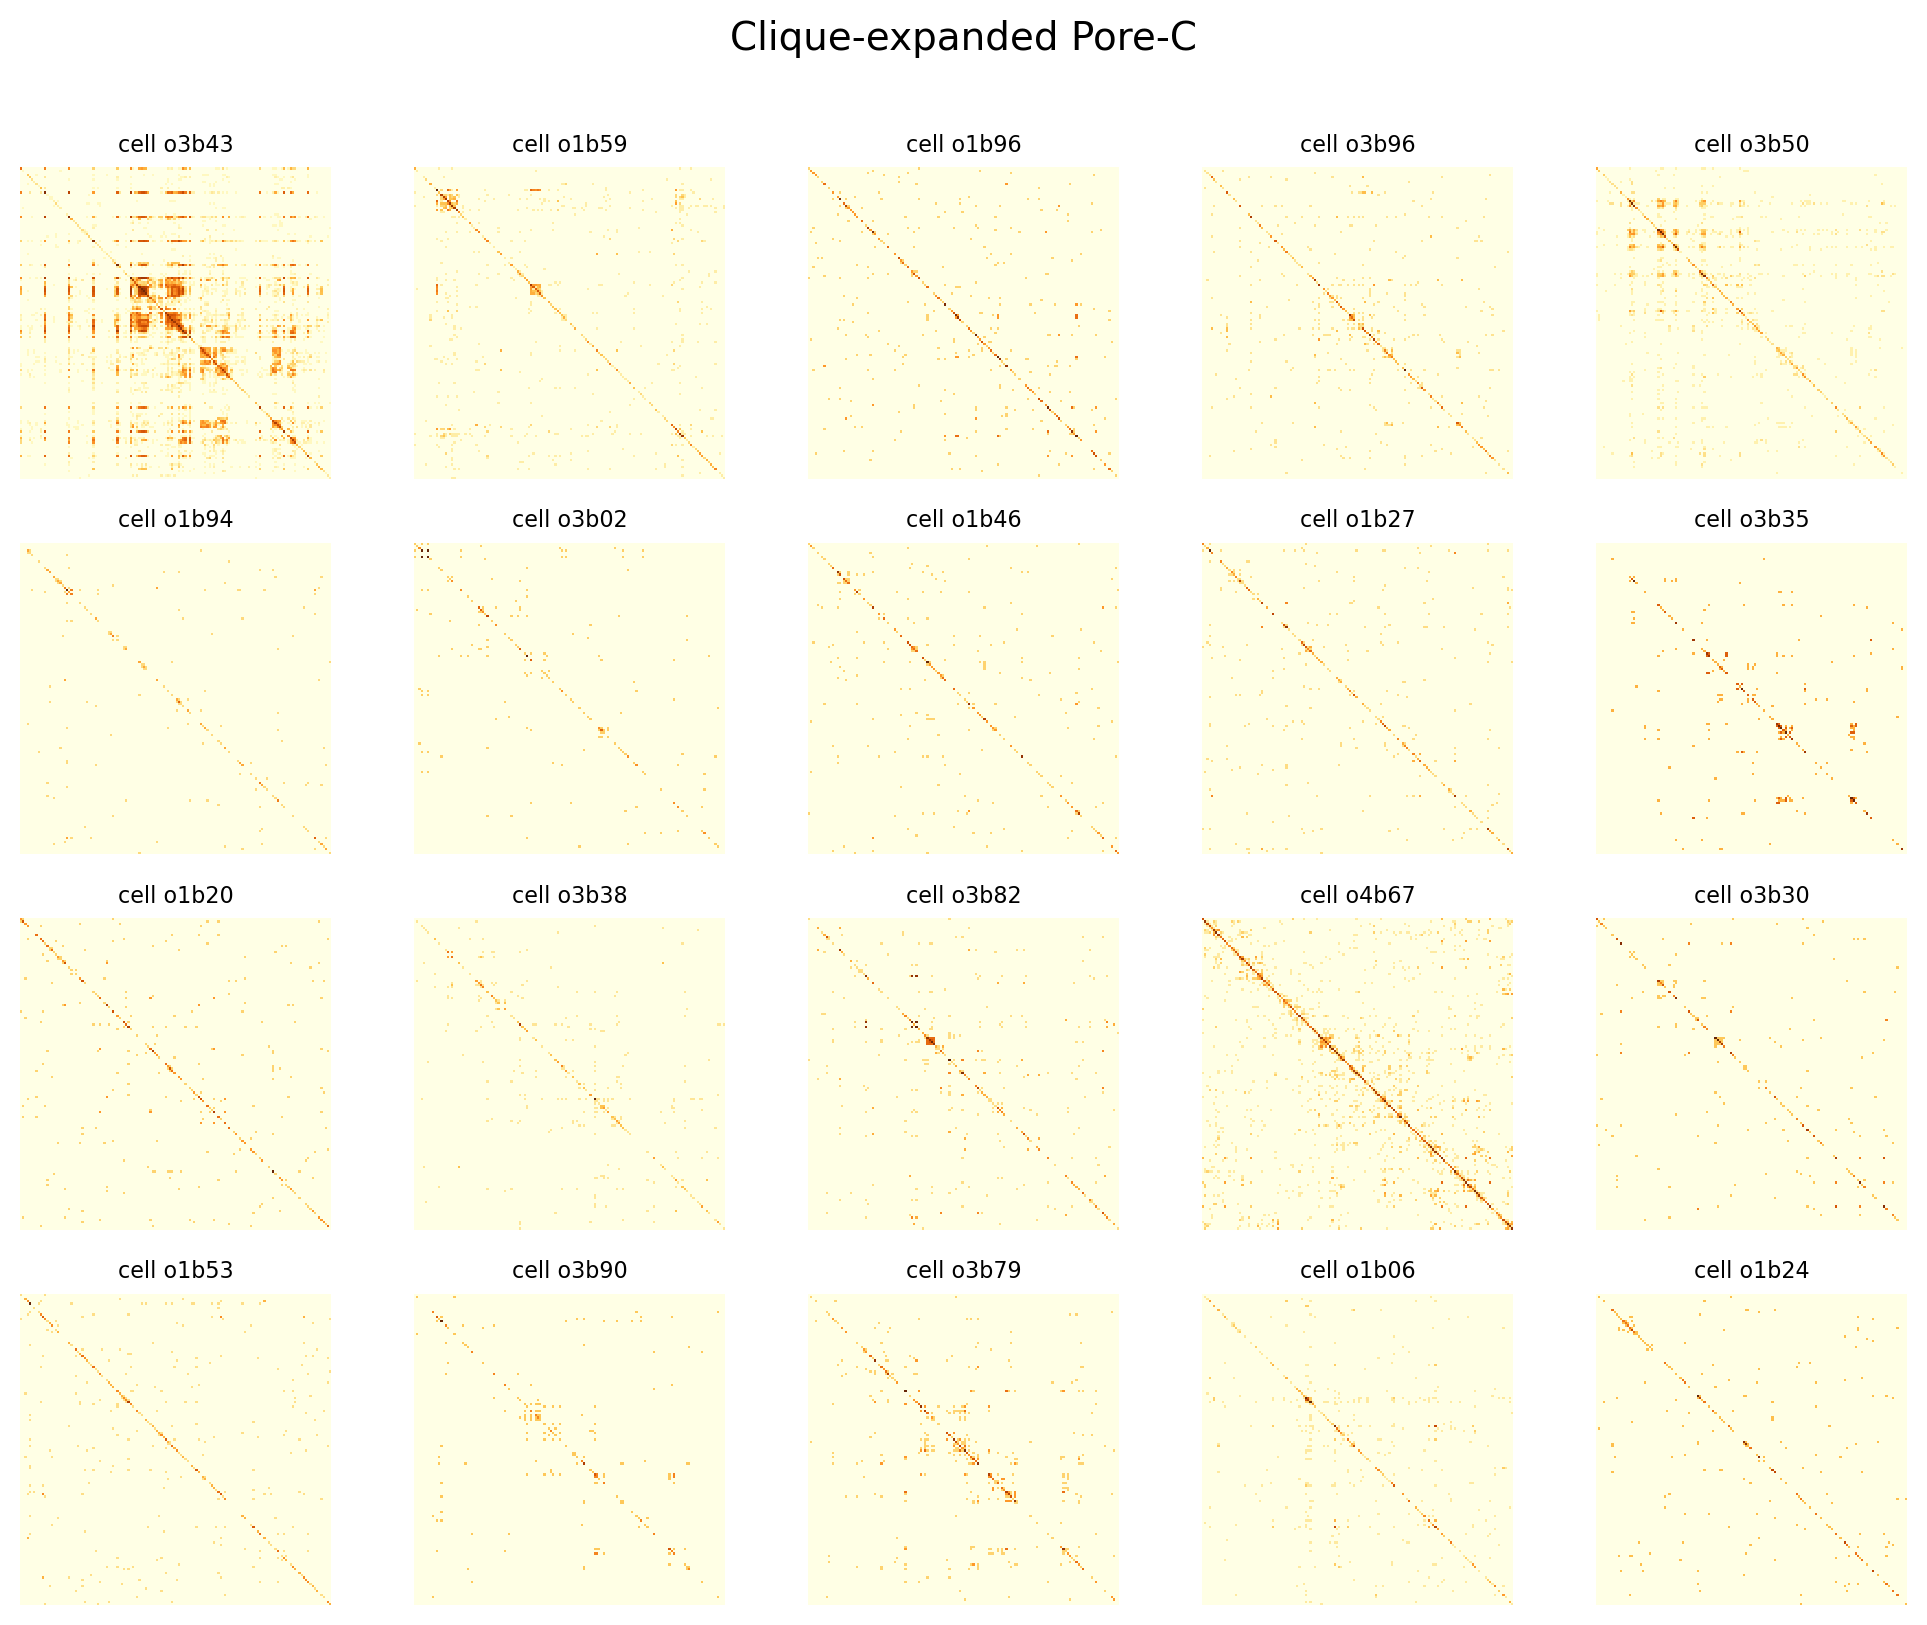

In [16]:
all_cell_ids = list(incidence_matrices.keys())

for i, batch in enumerate(chunk_list(all_cell_ids, 20)):
    plot_clique_grid(
        incidence_matrices,
        cell_ids=batch,
        n_cols=5,
        figsize=(10, 8),
        save_path=f"plots/grid_{i:03d}.png"
    )

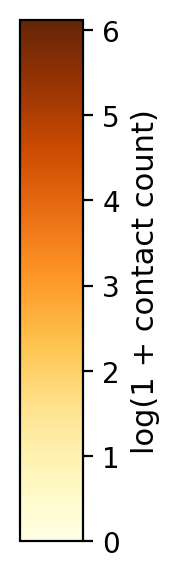

In [17]:
all_cell_ids = list(incidence_matrices.keys())

plot_clique_colorbar(
    incidence_matrices,
    cell_ids=all_cell_ids,
    save_path="plots/colorbar.png",
)

## Hi-C

In [23]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/poreC/data/f1219_population_hic/4DNFICF9PA9C.mcool"

chrom = "chr7"
clr = cooler.Cooler(f'{fpath}::resolutions/{resolution}')
Ahic = clr.matrix(balance=False).fetch(str(chrom))[:]
Ahic = np.nan_to_num(Ahic)
print(f"{Ahic.shape=}")

# drop the telomere
Ahic = Ahic[3:, :][:, 3:]
print(f"{Ahic.shape=}")

Ahic.shape=(146, 146)
Ahic.shape=(143, 143)


In [25]:
# sample files
dpath = "/nfs/turbo/umms-indikar/shared/projects/poreC/data/nagano2017/matrices/all_mats/"
sample_size = 20
sample_files = sample_file_paths(dpath, sample_size)
sample_files = [f"{x}/adj" for x in sample_files]

# contact specs
resolution = 1000000


nagano = []

for fpath in sample_files:
    
    cell_matrix = pd.read_csv(fpath, sep='\t')
    cell_matrix = join_fend_info(ref, cell_matrix)
    print(cell_matrix.head())
    break

Loaded 3882 cells, matrix shape: (150, 150)
